# MODULE 7 — EEGMMIDB → BCI-IV-2a Unsupervised Domain Adaptation

**Source:** 109 EEGMMIDB subjects  
**Target:** 9 BCI-IV-2a subjects  
**Input:** 22 channels × 640 samples, 160 Hz, 8–30 Hz, 3 classes

### Protocol
- EEGMMIDB labels are used for supervised source learning.
- BCI-IV-2a labels are **never used for training, model selection, temperature fitting, or threshold selection**.
- Unlabeled BCI EEG is used only for unsupervised domain alignment (DANN + CORAL + MMD).
- Final accuracy is computed only after adaptation, using the held-out BCI labels.
- This is **transductive unsupervised domain adaptation**, not ordinary LOSO.


In [1]:
# ============================================================
# CELL 1 — IMPORTS + REPRODUCIBILITY + DEVICE
# ============================================================

from __future__ import annotations

import os
import gc
import json
import copy
import math
import time
import random
import warnings
from pathlib import Path
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import h5py
import scipy.signal as sig
from scipy.linalg import eigh

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    log_loss,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)

print("Device:", device)

Device: mps


In [2]:
# ============================================================
# CELL 2 — AUTHORITATIVE PROJECT PATH DISCOVERY
# ============================================================
# The earlier modules define PROJECT_ROOT as:
#     /Users/ashokvarmabevara/Project2
#
# We preserve that path first, then provide safe fallbacks so
# the notebook can also run after the project directory has
# been moved/copied.

PROJECT_ROOT_CANDIDATES = [
    Path("/Users/ashokvarmabevara/Project2"),
    Path.cwd(),
    Path.home() / "Project2",
    Path("/mnt/data/Project2"),
]

PROJECT_ROOT = None

for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = Path(candidate)
    if (
        (candidate / "cross_dataset_mi_project").exists()
        or (candidate / "BCI IV-2a").exists()
        or (candidate / "eegmmidb").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    # Last-resort explicit path from Modules 1–6.
    PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
CACHE_ROOT = OUTPUT_ROOT / "cache"
RESULTS_ROOT = OUTPUT_ROOT / "results"
FIGURES_ROOT = OUTPUT_ROOT / "figures"
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"

for p in [
    RESULTS_ROOT,
    FIGURES_ROOT,
    CHECKPOINT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

FINAL_CACHE_PATH = (
    CACHE_ROOT
    / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_preprocessing_specification.json"
)

MODULE_6_LOSO_PATH = (
    MANIFEST_ROOT
    / "module_6_within_dataset_loso_folds.csv"
)

MODULE_6_CACHE_META_PATH = (
    MANIFEST_ROOT
    / "module_6_cache_metadata.csv"
)

MODULE_6_PROTOCOL_PATH = (
    MANIFEST_ROOT
    / "module_6_baseline_protocol.json"
)

print("=" * 78)
print("MODULE 7 — PROJECT INTERFACE")
print("=" * 78)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Cache       :", FINAL_CACHE_PATH)
print("Manifest    :", MANIFEST_ROOT)
print("Results     :", RESULTS_ROOT)
print("Figures     :", FIGURES_ROOT)

print("\nExistence:")
for name, p in [
    ("PROJECT_ROOT", PROJECT_ROOT),
    ("OUTPUT_ROOT", OUTPUT_ROOT),
    ("FINAL_CACHE_PATH", FINAL_CACHE_PATH),
    ("MODULE_5_SPEC_PATH", MODULE_5_SPEC_PATH),
    ("MODULE_6_LOSO_PATH", MODULE_6_LOSO_PATH),
    ("MODULE_6_CACHE_META_PATH", MODULE_6_CACHE_META_PATH),
]:
    print(f"  {name:28s}: {'PASS' if p.exists() else 'FAIL'}")

MODULE 7 — PROJECT INTERFACE
PROJECT_ROOT: /Users/ashokvarmabevara/Project2
Cache       : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
Manifest    : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests
Results     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results
Figures     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures

Existence:
  PROJECT_ROOT                : PASS
  OUTPUT_ROOT                 : PASS
  FINAL_CACHE_PATH            : PASS
  MODULE_5_SPEC_PATH          : PASS
  MODULE_6_LOSO_PATH          : PASS
  MODULE_6_CACHE_META_PATH    : PASS


In [3]:
# ============================================================
# CELL 3 — LOAD THE FROZEN MODULE 5/6 CONTRACT
# ============================================================

with open(MODULE_5_SPEC_PATH, "r", encoding="utf-8") as f:
    module_5_spec = json.load(f)

FROZEN_CHANNELS = [str(x) for x in module_5_spec["channels"]]
TARGET_SFREQ = float(module_5_spec["target_sfreq_hz"])
LOW_HZ, HIGH_HZ = map(float, module_5_spec["primary_bandpass_hz"])
N_SAMPLES = int(module_5_spec["epoch"]["n_samples"])
TMIN = float(module_5_spec["epoch"]["tmin_sec"])
TMAX = float(module_5_spec["epoch"]["tmax_sec"])

# Explicit 3-class project interface from Module 6.
CLASSES = ["left", "right", "feet"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
N_CLASSES = len(CLASSES)

print(json.dumps({
    "channels": FROZEN_CHANNELS,
    "n_channels": len(FROZEN_CHANNELS),
    "sampling_rate_hz": TARGET_SFREQ,
    "bandpass_hz": [LOW_HZ, HIGH_HZ],
    "epoch_sec": [TMIN, TMAX],
    "n_samples": N_SAMPLES,
    "classes": CLASS_TO_ID,
}, indent=2))

assert len(FROZEN_CHANNELS) == 22
assert TARGET_SFREQ == 160.0
assert (LOW_HZ, HIGH_HZ) == (8.0, 30.0)
assert N_SAMPLES == 640
assert abs((TMAX - TMIN) - 4.0) < 1e-9
assert N_CLASSES == 3

print("\nFrozen Module 5/6 interface: PASS")

{
  "channels": [
    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz"
  ],
  "n_channels": 22,
  "sampling_rate_hz": 160.0,
  "bandpass_hz": [
    8.0,
    30.0
  ],
  "epoch_sec": [
    0.0,
    4.0
  ],
  "n_samples": 640,
  "classes": {
    "left": 0,
    "right": 1,
    "feet": 2
  }
}

Frozen Module 5/6 interface: PASS


In [4]:
# ============================================================
# CELL 4 — LOAD + VERIFY FINAL HDF5 CACHE METADATA
# ============================================================

REQUIRED_META = [
    "dataset",
    "subject",
    "run",
    "recording_id",
    "filename",
    "absolute_path",
    "harmonized_class",
    "event_index",
    "onset_sec",
    "source_sfreq_hz",
]

def decode_strings(values):
    result = []
    for v in values:
        if isinstance(v, bytes):
            result.append(v.decode("utf-8"))
        else:
            result.append(str(v))
    return result

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_shape = tuple(h5["X"].shape)
    X_dtype = str(h5["X"].dtype)
    meta_keys = list(h5["metadata"].keys())

    missing = [k for k in REQUIRED_META if k not in meta_keys]
    cache_attrs = {k: h5.attrs[k] for k in h5.attrs.keys()}

    metadata = {}
    for key in [
        "dataset", "subject", "run", "recording_id",
        "filename", "absolute_path", "harmonized_class"
    ]:
        metadata[key] = decode_strings(h5["metadata"][key][:])

    metadata["event_index"] = h5["metadata"]["event_index"][:].astype(np.int64)
    metadata["onset_sec"] = h5["metadata"]["onset_sec"][:].astype(np.float64)
    metadata["source_sfreq_hz"] = h5["metadata"]["source_sfreq_hz"][:].astype(np.float64)

cache_meta_df = pd.DataFrame(metadata)
cache_meta_df.insert(0, "cache_index", np.arange(len(cache_meta_df), dtype=np.int64))

print("=" * 78)
print("CACHE CONTRACT")
print("=" * 78)
print("Shape :", X_shape)
print("Dtype :", X_dtype)
print("Epochs:", len(cache_meta_df))
print("Meta  :", meta_keys)

assert not missing, f"Missing metadata: {missing}"
assert X_shape[1:] == (22, 640)
assert X_dtype == "float32"
assert set(cache_meta_df["harmonized_class"].unique()) == set(CLASSES)
assert cache_meta_df["subject"].nunique() == 118

dataset_summary = (
    cache_meta_df
    .groupby(["dataset", "harmonized_class"])
    .size()
    .unstack(fill_value=0)
)

display(dataset_summary)

print("\n118-subject / 3-class / 22×640 cache contract: PASS")

CACHE CONTRACT
Shape : (9316, 22, 640)
Dtype : float32
Epochs: 9316
Meta  : ['absolute_path', 'dataset', 'event_index', 'filename', 'harmonized_class', 'onset_sec', 'recording_id', 'run', 'source_sfreq_hz', 'subject']


harmonized_class,feet,left,right
dataset,,,
BCI-IV-2a,648,648,648
EEGMMIDB,2455,2479,2438



118-subject / 3-class / 22×640 cache contract: PASS


In [5]:
# ============================================================
# CELL 5 — FIXED NUMERICAL QA + CACHE LOAD
# ============================================================
# Loads the authoritative Module-6 HDF5 cache first, then
# performs numerical QA.
#
# Module-6 cache:
#   X              -> EEG epochs
#   metadata       -> labels / subjects / dataset information
#
# Expected:
#   9316 epochs
#   22 channels
#   640 samples
#   118 subjects
#   3 classes
# ============================================================

import os
import json
import h5py
import numpy as np
import pandas as pd

print("=" * 72)
print("MODULE 7 — NUMERICAL QA + CACHE LOAD")
print("=" * 72)

# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

from pathlib import Path

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

# Allow execution from another machine/path if PROJECT_ROOT
# was already defined in an earlier notebook cell.
if "PROJECT_ROOT" in globals():
    PROJECT_ROOT = Path(PROJECT_ROOT)

PROJECT_DIR = PROJECT_ROOT / "cross_dataset_mi_project"
CACHE_ROOT = PROJECT_DIR / "cache"
MANIFEST_ROOT = PROJECT_DIR / "manifests"

FINAL_CACHE_PATH = (
    CACHE_ROOT /
    "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT /
    "module_5_v2_preprocessing_specification.json"
)

CACHE_META_PATH = (
    MANIFEST_ROOT /
    "module_6_cache_metadata.csv"
)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nCache:")
print(FINAL_CACHE_PATH)

# ------------------------------------------------------------
# 2. Validate paths
# ------------------------------------------------------------

if not FINAL_CACHE_PATH.exists():
    raise FileNotFoundError(
        "\nModule-6 cache was not found:\n"
        f"{FINAL_CACHE_PATH}\n\n"
        "Check PROJECT_ROOT in this cell."
    )

print("\nCache exists: YES")

# ------------------------------------------------------------
# 3. Load Module-5 specification if available
# ------------------------------------------------------------

module_5_spec = {}

if MODULE_5_SPEC_PATH.exists():
    with open(MODULE_5_SPEC_PATH, "r") as f:
        module_5_spec = json.load(f)

print(
    "Module-5 specification:",
    "FOUND" if MODULE_5_SPEC_PATH.exists() else "NOT FOUND"
)

# ------------------------------------------------------------
# 4. Inspect HDF5 structure
# ------------------------------------------------------------

with h5py.File(FINAL_CACHE_PATH, "r") as h5:

    print("\nHDF5 datasets/groups:")

    def print_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"  {name:<35} "
                f"shape={obj.shape} "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"  {name}/")

    h5.visititems(print_h5)

    assert "X" in h5, (
        "Authoritative cache does not contain dataset 'X'."
    )

    X_shape = tuple(h5["X"].shape)

print("\nCache X shape:", X_shape)

# ------------------------------------------------------------
# 5. Load EEG data
# ------------------------------------------------------------
# Module 6 defines the authoritative EEG array as h5["X"].
# Load it into RAM for Module 7.

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_raw = np.asarray(
        h5["X"][:],
        dtype=np.float32
    )

print(
    f"\nX_raw loaded successfully: "
    f"{X_raw.shape}, dtype={X_raw.dtype}"
)

# ------------------------------------------------------------
# 6. Load metadata
# ------------------------------------------------------------

if CACHE_META_PATH.exists():

    cache_meta_df = pd.read_csv(CACHE_META_PATH)

    print(
        "\nMetadata rows:",
        len(cache_meta_df)
    )

else:

    # Fall back to metadata stored inside HDF5.
    print(
        "\nWARNING: module_6_cache_metadata.csv not found."
    )

    with h5py.File(FINAL_CACHE_PATH, "r") as h5:

        assert "metadata" in h5, (
            "No CSV metadata and no HDF5 metadata group found."
        )

        metadata = {}

        for key in h5["metadata"].keys():

            arr = h5["metadata"][key][:]

            if arr.dtype.kind in {"S", "O"}:
                arr = np.array(
                    [
                        x.decode("utf-8")
                        if isinstance(x, bytes)
                        else str(x)
                        for x in arr
                    ]
                )

            metadata[key] = arr

    cache_meta_df = pd.DataFrame(metadata)

print("\nMetadata columns:")
print(cache_meta_df.columns.tolist())

# ------------------------------------------------------------
# 7. Resolve labels
# ------------------------------------------------------------

LABEL_CANDIDATES = [
    "label",
    "labels",
    "class",
    "harmonized_class",
]

label_col = None

for c in LABEL_CANDIDATES:
    if c in cache_meta_df.columns:
        label_col = c
        break

if label_col is None:
    raise KeyError(
        "Could not locate class labels in cache metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

# Text class labels → integer labels
if cache_meta_df[label_col].dtype.kind in {"U", "S", "O"}:

    class_names = sorted(
        cache_meta_df[label_col]
        .astype(str)
        .unique()
        .tolist()
    )

    class_to_id = {
        name: i
        for i, name in enumerate(class_names)
    }

    y = (
        cache_meta_df[label_col]
        .astype(str)
        .map(class_to_id)
        .to_numpy(dtype=np.int64)
    )

    CLASSES = class_names

else:

    y = cache_meta_df[label_col].to_numpy(
        dtype=np.int64
    )

    unique_labels = sorted(
        np.unique(y).tolist()
    )

    # Preserve explicit class names when available.
    CLASSES = [str(x) for x in unique_labels]

print("\nLabel column:", label_col)
print("Classes:", CLASSES)
print("Encoded labels:", np.unique(y))

# ------------------------------------------------------------
# 8. Resolve subject IDs
# ------------------------------------------------------------

SUBJECT_CANDIDATES = [
    "subject",
    "subject_id",
    "subject_uid",
]

subject_col = None

for c in SUBJECT_CANDIDATES:
    if c in cache_meta_df.columns:
        subject_col = c
        break

if subject_col is None:
    raise KeyError(
        "Could not locate subject IDs in metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

subjects = (
    cache_meta_df[subject_col]
    .astype(str)
    .to_numpy()
)

# ------------------------------------------------------------
# 9. Resolve dataset IDs
# ------------------------------------------------------------

DATASET_CANDIDATES = [
    "dataset",
    "dataset_name",
    "source_dataset",
]

dataset_col = None

for c in DATASET_CANDIDATES:
    if c in cache_meta_df.columns:
        dataset_col = c
        break

if dataset_col is not None:

    datasets = (
        cache_meta_df[dataset_col]
        .astype(str)
        .to_numpy()
    )

else:

    datasets = np.array(
        ["unknown"] * len(y),
        dtype=str
    )

# ------------------------------------------------------------
# 10. Basic consistency checks
# ------------------------------------------------------------

assert len(X_raw) == len(y), (
    f"X/y mismatch: {len(X_raw)} vs {len(y)}"
)

assert len(X_raw) == len(subjects), (
    f"X/subject mismatch: "
    f"{len(X_raw)} vs {len(subjects)}"
)

assert X_raw.ndim == 3, (
    f"Expected X=(N,C,T), got {X_raw.shape}"
)

N_EPOCHS, N_CHANNELS, N_SAMPLES = X_raw.shape

print("\nData interface:")
print(f"  epochs     : {N_EPOCHS}")
print(f"  channels   : {N_CHANNELS}")
print(f"  samples    : {N_SAMPLES}")
print(f"  classes    : {len(CLASSES)}")
print(f"  subjects   : {len(np.unique(subjects))}")

# ------------------------------------------------------------
# 11. Numerical QA
# ------------------------------------------------------------

nonfinite_mask = ~np.isfinite(X_raw)
nonfinite = int(nonfinite_mask.sum())

epoch_var = np.var(
    X_raw,
    axis=(1, 2)
)

zero_var_mask = epoch_var <= 1e-12
zero_var = int(zero_var_mask.sum())

print("\nNumerical QA:")
print(f"  Non-finite values   : {nonfinite}")
print(f"  Zero-variance epochs: {zero_var}")

# Non-finite values are a hard failure.
assert nonfinite == 0, (
    f"Found {nonfinite} non-finite values."
)

# Zero variance is a diagnostic condition, NOT an assertion.
print(
    "\nNumerical QA: PASS"
)

print(
    f"Zero-variance epochs retained in frozen cache: "
    f"{zero_var}"
)

# ------------------------------------------------------------
# 12. Dataset statistics
# ------------------------------------------------------------

print("\nClass distribution:")

class_counts = pd.Series(
    y
).value_counts().sort_index()

for cls_id, count in class_counts.items():

    cls_name = (
        CLASSES[int(cls_id)]
        if int(cls_id) < len(CLASSES)
        else str(cls_id)
    )

    print(
        f"  {cls_id} ({cls_name}): {count}"
    )

# ------------------------------------------------------------
# 13. Subject statistics
# ------------------------------------------------------------

subject_dataset = pd.DataFrame({
    "subject": subjects,
    "dataset": datasets,
})

subject_dataset["epochs"] = 1

subject_dataset = (
    subject_dataset
    .groupby(
        ["dataset", "subject"],
        as_index=False
    )["epochs"]
    .sum()
)

print("\nDataset / subject epoch statistics:")

display(
    subject_dataset.groupby("dataset")["epochs"]
    .agg(
        subjects="count",
        min_epochs="min",
        median_epochs="median",
        mean_epochs="mean",
        max_epochs="max",
    )
    .reset_index()
)

# ------------------------------------------------------------
# 14. Store zero-variance indices
# ------------------------------------------------------------

ZERO_VAR_INDICES = np.flatnonzero(
    zero_var_mask
).astype(np.int64)

ZERO_VAR_MASK = zero_var_mask

print(
    "\nZERO_VAR_INDICES:",
    len(ZERO_VAR_INDICES)
)

# ------------------------------------------------------------
# 15. Final interface summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("MODULE 7 DATA INTERFACE READY")
print("=" * 72)

print(f"Cache      : {FINAL_CACHE_PATH}")
print(f"X_raw      : {X_raw.shape}")
print(f"Labels     : {y.shape}")
print(f"Subjects   : {subjects.shape}")
print(f"Datasets   : {datasets.shape}")
print(f"Classes    : {CLASSES}")
print(f"Zero-var   : {zero_var}")
print(f"Nonfinite  : {nonfinite}")

print("\n✅ Cell 5 completed successfully.")

MODULE 7 — NUMERICAL QA + CACHE LOAD

Project root:
/Users/ashokvarmabevara/Project2

Cache:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5

Cache exists: YES
Module-5 specification: FOUND

HDF5 datasets/groups:
  X                                   shape=(9316, 22, 640) dtype=float32
  metadata/
  metadata/absolute_path              shape=(9316,) dtype=object
  metadata/dataset                    shape=(9316,) dtype=object
  metadata/event_index                shape=(9316,) dtype=int64
  metadata/filename                   shape=(9316,) dtype=object
  metadata/harmonized_class           shape=(9316,) dtype=object
  metadata/onset_sec                  shape=(9316,) dtype=float64
  metadata/recording_id               shape=(9316,) dtype=object
  metadata/run                        shape=(9316,) dtype=object
  metadata/source_sfreq_hz            shape=(9316,) dtype=float64
  metadata/subject                    sh

,dataset,subjects,min_epochs,median_epochs,mean_epochs,max_epochs
0,BCI-IV-2a,9,216,216.0,216.000000,216
1,EEGMMIDB,109,54,68.0,67.633028,85



ZERO_VAR_INDICES: 0

MODULE 7 DATA INTERFACE READY
Cache      : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
X_raw      : (9316, 22, 640)
Labels     : (9316,)
Subjects   : (9316,)
Datasets   : (9316,)
Classes    : ['feet', 'left', 'right']
Zero-var   : 0
Nonfinite  : 0

✅ Cell 5 completed successfully.


In [6]:
# ============================================================
# CELL 6 — LEAKAGE-SAFE SOURCE-ONLY ROBUST NORMALIZATION
# ============================================================

class SourceOnlyRobustNormalizer:
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.fitted_subjects_ = tuple()

    def fit(self, X_source, source_subjects):
        X_source = np.asarray(X_source, dtype=np.float64)
        source_subjects = [str(s) for s in source_subjects]

        if X_source.ndim != 3 or X_source.shape[1:] != (22, 640):
            raise ValueError(f"Expected (N,22,640), got {X_source.shape}")

        values = X_source.transpose(1, 0, 2).reshape(22, -1)

        self.median_ = np.median(values, axis=1)
        q25 = np.percentile(values, 25, axis=1)
        q75 = np.percentile(values, 75, axis=1)
        self.iqr_ = np.maximum(q75 - q25, self.eps)

        self.fitted_subjects_ = tuple(sorted(set(source_subjects)))
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (
            (X - self.median_[None, :, None])
            / (self.iqr_[None, :, None] + self.eps)
        ).astype(np.float32)

    def assert_target_excluded(self, target_subject):
        if str(target_subject) in set(self.fitted_subjects_):
            raise AssertionError(
                f"LEAKAGE: {target_subject} was used for normalization."
            )

print("Normalizer: ready")

Normalizer: ready


In [7]:
# ============================================================
# CELL 7 — HDF5 RANDOM-ACCESS HELPERS
# ============================================================

class HDF5EpochStore:
    def __init__(self, path):
        self.path = Path(path)
        self._h5 = None

    def __enter__(self):
        self._h5 = h5py.File(self.path, "r")
        return self

    def __exit__(self, exc_type, exc, tb):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    @property
    def shape(self):
        return tuple(self._h5["X"].shape)

    def get_X(self, indices):
        indices = np.asarray(indices, dtype=np.int64)
        order = np.argsort(indices)
        sorted_idx = indices[order]
        values = np.asarray(self._h5["X"][sorted_idx], dtype=np.float32)
        return values[np.argsort(order)]

def load_indices(indices):
    with HDF5EpochStore(FINAL_CACHE_PATH) as store:
        return store.get_X(indices)

print("HDF5 loader:", load_indices([0, 1]).shape)

HDF5 loader: (2, 22, 640)


In [8]:
# ============================================================
# CELL 8 — SUBJECT-WISE FOLDS + INNER VALIDATION
# ============================================================

def parse_json_indices(s):
    return np.asarray(json.loads(s), dtype=np.int64)

# Prefer Module 6's authoritative LOSO manifest when available.
if MODULE_6_LOSO_PATH.exists():
    within_loso_df = pd.read_csv(MODULE_6_LOSO_PATH)
else:
    rows = []
    for dataset_name in sorted(cache_meta_df["dataset"].unique()):
        ds = cache_meta_df[cache_meta_df["dataset"] == dataset_name]
        for fold_id, target_subject in enumerate(sorted(ds["subject"].unique())):
            train_idx = ds.loc[ds["subject"] != target_subject, "cache_index"].tolist()
            test_idx = ds.loc[ds["subject"] == target_subject, "cache_index"].tolist()
            rows.append({
                "protocol": "within_dataset_loso",
                "dataset": dataset_name,
                "fold_id": fold_id,
                "target_subject": target_subject,
                "train_indices_json": json.dumps(train_idx),
                "test_indices_json": json.dumps(test_idx),
            })
    within_loso_df = pd.DataFrame(rows)

# Normalize manifest column naming across versions.
if "target_subject" not in within_loso_df.columns:
    raise RuntimeError("Module 6 LOSO manifest has no target_subject column.")

print("Within-dataset folds:", len(within_loso_df))
display(within_loso_df[[
    "dataset", "fold_id", "target_subject",
    "source_train_subject_count" if "source_train_subject_count" in within_loso_df.columns else "target_subject"
]].head())

def make_inner_subject_split(train_subjects, seed=SEED, val_fraction=0.20):
    subjects = np.array(sorted(set(map(str, train_subjects))))
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_val = max(1, int(round(len(subjects) * val_fraction)))
    n_val = min(n_val, len(subjects) - 1)

    return set(subjects[n_val:]), set(subjects[:n_val])

def make_balanced_sample_weights(y):
    y = np.asarray(y, dtype=np.int64)
    counts = np.bincount(y, minlength=N_CLASSES).astype(np.float64)
    weights = np.zeros_like(counts)
    weights[counts > 0] = 1.0 / counts[counts > 0]
    return weights[y]

print("Inner validation splitter: ready")

Within-dataset folds: 118


,dataset,fold_id,target_subject,source_train_subject_count
0,BCI-IV-2a,0,S01,8
1,BCI-IV-2a,1,S02,8
2,BCI-IV-2a,2,S03,8
3,BCI-IV-2a,3,S04,8
4,BCI-IV-2a,4,S05,8


Inner validation splitter: ready


In [9]:
# ============================================================
# CELL 9 — EEG AUGMENTATION FOR SOURCE TRAINING
# ============================================================

def augment_eeg_batch(
    xb,
    p_noise=0.35,
    p_scale=0.45,
    p_shift=0.35,
    p_channel_drop=0.15,
):
    # xb: [B,C,T]
    out = xb

    if torch.rand(1, device=xb.device).item() < p_scale:
        scale = torch.empty(
            xb.size(0), 1, 1, device=xb.device
        ).uniform_(0.85, 1.15)
        out = out * scale

    if torch.rand(1, device=xb.device).item() < p_noise:
        noise = 0.02 * torch.randn_like(out)
        out = out + noise

    if torch.rand(1, device=xb.device).item() < p_shift:
        max_shift = max(1, int(0.08 * xb.size(-1)))
        shift = int(
            torch.randint(
                -max_shift,
                max_shift + 1,
                (1,),
                device=xb.device,
            ).item()
        )
        if shift != 0:
            out = torch.roll(out, shifts=shift, dims=-1)

    if torch.rand(1, device=xb.device).item() < p_channel_drop:
        mask = torch.ones(
            xb.size(0), xb.size(1), 1,
            device=xb.device
        )
        n_drop = max(1, int(round(0.05 * xb.size(1))))
        for b in range(xb.size(0)):
            idx = torch.randperm(xb.size(1), device=xb.device)[:n_drop]
            mask[b, idx, :] = 0.0
        out = out * mask

    return out

print("EEG augmentation: ready")

EEG augmentation: ready


## Cells 10–23: cross-dataset domain adaptation

The next cells replace the previous FBCSP/fusion-first path. The classifier is trained on EEGMMIDB labels while the feature extractor is aligned to the unlabeled BCI-IV-2a distribution.


In [10]:

# ============================================================
# CELL 10 — DANN + CORAL + MMD EEGNET
# ============================================================

class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = float(lambd)
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReversalLayer(nn.Module):
    def forward(self, x, lambd=1.0):
        return GradientReversalFn.apply(x, lambd)


class DomainAdaptEEGNet(nn.Module):
    """EEGNet backbone with class and dataset-domain heads."""

    def __init__(
        self,
        n_ch=22,
        n_t=640,
        n_cls=3,
        embedding_dim=128,
        F1=12,
        D=2,
        F2=24,
        dropout=0.35,
    ):
        super().__init__()

        self.input_norm = nn.InstanceNorm2d(
            1, affine=False, track_running_stats=False
        )

        self.t15 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 15), padding=(0, 7), bias=False),
            nn.GroupNorm(4, F1),
            nn.ELU(),
        )
        self.t31 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 31), padding=(0, 15), bias=False),
            nn.GroupNorm(4, F1),
            nn.ELU(),
        )
        self.t63 = nn.Sequential(
            nn.Conv2d(1, F1, (1, 63), padding=(0, 31), bias=False),
            nn.GroupNorm(4, F1),
            nn.ELU(),
        )

        self.scale_fusion = nn.Sequential(
            nn.Conv2d(3 * F1, F1, (1, 1), bias=False),
            nn.GroupNorm(4, F1),
            nn.ELU(),
        )

        self.spatial = nn.Sequential(
            nn.Conv2d(
                F1,
                F1 * D,
                (n_ch, 1),
                groups=F1,
                bias=False,
            ),
            nn.GroupNorm(6, F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        self.separable = nn.Sequential(
            nn.Conv2d(
                F1 * D,
                F1 * D,
                (1, 15),
                padding=(0, 7),
                groups=F1 * D,
                bias=False,
            ),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.GroupNorm(6, F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(2, 1, n_ch, n_t)
            z = self._features(dummy)
            flat_dim = z.flatten(1).shape[1]

        self.embedding = nn.Sequential(
            nn.Linear(flat_dim, embedding_dim),
            nn.LayerNorm(embedding_dim),
            nn.ELU(),
            nn.Dropout(0.20),
        )

        self.classifier = nn.Linear(embedding_dim, n_cls)

        # Source-vs-target dataset discriminator.
        self.domain_head = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 2),
        )

        self.grl = GradientReversalLayer()
        self.feature_dim = embedding_dim

    def _features(self, x):
        x = self.input_norm(x)
        z1 = self.t15(x)
        z2 = self.t31(x)
        z3 = self.t63(x)
        z = torch.cat([z1, z2, z3], dim=1)
        z = self.scale_fusion(z)
        z = self.spatial(z)
        z = self.separable(z)
        return z

    def extract(self, x):
        z = self._features(x.unsqueeze(1))
        return self.embedding(z.flatten(1))

    def forward(self, x, domain_lambda=0.0):
        feat = self.extract(x)
        class_logits = self.classifier(feat)
        domain_logits = self.domain_head(
            self.grl(feat, domain_lambda)
        ) if domain_lambda > 0 else None
        return class_logits, feat, domain_logits


model_probe = DomainAdaptEEGNet(
    n_ch=22,
    n_t=640,
    n_cls=N_CLASSES,
)

print("Domain adaptation EEGNet ready")
print("Embedding dimension:", model_probe.feature_dim)


Domain adaptation EEGNet ready
Embedding dimension: 128


In [11]:

# ============================================================
# CELL 11 — TRANSFER DATA PREPARATION
# ============================================================

SOURCE_DATASET = "EEGMMIDB"
TARGET_DATASET = "BCI-IV-2a"

transfer_meta = cache_meta_df.copy()
transfer_meta["dataset"] = transfer_meta["dataset"].astype(str)
transfer_meta["subject"] = transfer_meta["subject"].astype(str)

source_meta = transfer_meta[transfer_meta["dataset"] == SOURCE_DATASET].copy()
target_meta = transfer_meta[transfer_meta["dataset"] == TARGET_DATASET].copy()

source_subjects = sorted(source_meta["subject"].unique())
target_subjects = sorted(target_meta["subject"].unique())

assert len(source_subjects) == 109
assert len(target_subjects) == 9

print("Source subjects:", len(source_subjects))
print("Target subjects:", len(target_subjects))
print("Target list:", target_subjects)

# Source-only validation subjects. BCI is never used here.
source_train_subjects, source_val_subjects = make_inner_subject_split(
    source_subjects,
    seed=SEED,
    val_fraction=0.20,
)

source_train_subjects = sorted(map(str, source_train_subjects))
source_val_subjects = sorted(map(str, source_val_subjects))

source_train_mask = (
    (transfer_meta["dataset"] == SOURCE_DATASET)
    & transfer_meta["subject"].isin(source_train_subjects)
)
source_val_mask = (
    (transfer_meta["dataset"] == SOURCE_DATASET)
    & transfer_meta["subject"].isin(source_val_subjects)
)
target_mask = transfer_meta["dataset"] == TARGET_DATASET

SOURCE_TRAIN_IDX = transfer_meta.loc[source_train_mask, "cache_index"].to_numpy(np.int64)
SOURCE_VAL_IDX = transfer_meta.loc[source_val_mask, "cache_index"].to_numpy(np.int64)
TARGET_IDX = transfer_meta.loc[target_mask, "cache_index"].to_numpy(np.int64)

X_source_train_raw = load_indices(SOURCE_TRAIN_IDX)
X_source_val_raw = load_indices(SOURCE_VAL_IDX)
X_target_raw = load_indices(TARGET_IDX)

y_source_train = transfer_meta.loc[source_train_mask, "harmonized_class"].map(CLASS_TO_ID).to_numpy(np.int64)
y_source_val = transfer_meta.loc[source_val_mask, "harmonized_class"].map(CLASS_TO_ID).to_numpy(np.int64)
y_target = transfer_meta.loc[target_mask, "harmonized_class"].map(CLASS_TO_ID).to_numpy(np.int64)

source_train_subject_ids = transfer_meta.loc[source_train_mask, "subject"].astype(str).to_numpy()

print("\nShapes:")
print("  source train:", X_source_train_raw.shape)
print("  source val  :", X_source_val_raw.shape)
print("  target       :", X_target_raw.shape)

assert X_source_train_raw.shape[1:] == (22, 640)
assert X_source_val_raw.shape[1:] == (22, 640)
assert X_target_raw.shape[1:] == (22, 640)


Source subjects: 109
Target subjects: 9
Target list: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09']

Shapes:
  source train: (5886, 22, 640)
  source val  : (1486, 22, 640)
  target       : (1944, 22, 640)


In [12]:

# ============================================================
# CELL 12 — SOURCE-ONLY CLEANING + NORMALIZATION
# ============================================================

# Remove constant epochs ONLY from supervised source training.
source_std = np.std(X_source_train_raw, axis=(1, 2))
keep = np.isfinite(source_std) & (source_std >= 1e-6)

print("Constant source-training epochs removed:", int((~keep).sum()))

X_source_train = X_source_train_raw[keep]
y_source_train_clean = y_source_train[keep]
source_train_subject_ids_clean = source_train_subject_ids[keep]

# The first normalizer is source-only. It never sees BCI samples.
source_normalizer = SourceOnlyRobustNormalizer().fit(
    X_source_train,
    source_train_subject_ids_clean,
)

X_source_train_n = np.nan_to_num(
    source_normalizer.transform(X_source_train),
    nan=0.0, posinf=0.0, neginf=0.0,
).astype(np.float32)

X_source_val_n = np.nan_to_num(
    source_normalizer.transform(X_source_val_raw),
    nan=0.0, posinf=0.0, neginf=0.0,
).astype(np.float32)

X_target_n = np.nan_to_num(
    source_normalizer.transform(X_target_raw),
    nan=0.0, posinf=0.0, neginf=0.0,
).astype(np.float32)

print("Normalized:")
print("  train:", X_source_train_n.shape)
print("  val  :", X_source_val_n.shape)
print("  target:", X_target_n.shape)

# Domain IDs for source subjects are used only in optional subject-statistics monitoring.
CURRENT_TRAIN_SUBJECTS = source_train_subject_ids_clean.copy()
globals()["CURRENT_TRAIN_SUBJECTS"] = CURRENT_TRAIN_SUBJECTS


Constant source-training epochs removed: 0
Normalized:
  train: (5886, 22, 640)
  val  : (1486, 22, 640)
  target: (1944, 22, 640)


In [14]:
# ============================================================
# CELL 13 — SOURCE-ONLY SUPERVISED PRETRAINING
# FIXED: SELF-CONTAINED DATA LOADER
# ============================================================

# ------------------------------------------------------------
# 1. Source training DataLoader
# ------------------------------------------------------------

def make_loader(
    X,
    y,
    batch_size=64,
    train=True,
):
    """
    Build a PyTorch DataLoader for EEG data.

    X:
        (N, C, T)

    y:
        (N,)

    Training:
        class-balanced WeightedRandomSampler

    Validation:
        deterministic sequential batches
    """

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    y = np.asarray(
        y,
        dtype=np.int64,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X shape (N,C,T), got {X.shape}"
        )

    if len(X) != len(y):
        raise ValueError(
            f"X/y length mismatch: "
            f"{len(X)} vs {len(y)}"
        )

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y),
    )

    if train:

        weights = make_balanced_sample_weights(
            y
        )

        sampler = WeightedRandomSampler(
            torch.as_tensor(
                weights,
                dtype=torch.double,
            ),
            num_samples=len(y),
            replacement=True,
        )

        return DataLoader(
            dataset,
            batch_size=batch_size,
            sampler=sampler,
            drop_last=False,
            num_workers=0,
        )

    else:

        return DataLoader(
            dataset,
            batch_size=min(
                128,
                max(
                    16,
                    batch_size * 2,
                ),
            ),
            shuffle=False,
            drop_last=False,
            num_workers=0,
        )


# ------------------------------------------------------------
# 2. Model prediction
# ------------------------------------------------------------

@torch.no_grad()
def predict_da_model(
    model,
    X,
):
    """
    Predict class probabilities using the domain-adaptation
    EEGNet model.

    Domain branch is disabled during inference.
    """

    model.eval()

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(X),
        torch.zeros(
            len(X),
            dtype=torch.long,
        ),
    )

    loader = DataLoader(
        dataset,
        batch_size=128,
        shuffle=False,
        num_workers=0,
    )

    outputs = []

    for xb, _ in loader:

        xb = xb.to(
            device,
            non_blocking=True,
        )

        logits, feat, domain_logits = (
            model(
                xb,
                domain_lambda=0.0,
            )
        )

        outputs.append(
            logits.cpu().numpy()
        )

    logits = np.vstack(
        outputs
    )

    # Stable softmax.
    logits -= logits.max(
        axis=1,
        keepdims=True,
    )

    probabilities = np.exp(
        logits
    )

    probabilities /= (
        probabilities.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return probabilities


# ------------------------------------------------------------
# 3. Source-only supervised pretraining
# ------------------------------------------------------------

def train_source_pretrain(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=80,
    batch_size=64,
    lr=5e-4,
    patience=15,
):
    """
    Stage 1:
        Train the EEG feature extractor using ONLY labeled
        EEGMMIDB source data.

    No BCI target data is used here.
    """

    X_train = np.asarray(
        X_train,
        dtype=np.float32,
    )

    y_train = np.asarray(
        y_train,
        dtype=np.int64,
    )

    X_val = np.asarray(
        X_val,
        dtype=np.float32,
    )

    y_val = np.asarray(
        y_val,
        dtype=np.int64,
    )

    print(
        "\n" + "=" * 72
    )

    print(
        "SOURCE-ONLY EEGNET PRETRAINING"
    )

    print(
        "=" * 72
    )

    print(
        "Train shape:",
        X_train.shape
    )

    print(
        "Val shape  :",
        X_val.shape
    )

    print(
        "Train subjects:",
        len(
            np.unique(
                CURRENT_TRAIN_SUBJECTS
            )
        )
        if "CURRENT_TRAIN_SUBJECTS" in globals()
        else "not tracked",
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = DomainAdaptEEGNet(
        n_ch=X_train.shape[1],
        n_t=X_train.shape[2],
        n_cls=N_CLASSES,
    ).to(device)

    # --------------------------------------------------------
    # Class-balanced supervised loss
    # --------------------------------------------------------

    counts = np.bincount(
        y_train,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_w = (
        counts.sum()
        / (
            N_CLASSES
            * np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_w /= (
        class_w.mean()
        + 1e-12
    )

    class_w = torch.tensor(
        class_w,
        dtype=torch.float32,
        device=device,
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_w,
        label_smoothing=0.02,
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=3e-4,
    )

    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=2e-6,
        )
    )

    # --------------------------------------------------------
    # Loader
    # --------------------------------------------------------

    loader = make_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        train=True,
    )

    # --------------------------------------------------------
    # Early stopping state
    # --------------------------------------------------------

    best_state = None
    best_val = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------

    for ep in range(
        1,
        epochs + 1,
    ):

        model.train()

        train_predictions = []
        train_targets = []
        losses = []

        for xb, yb in loader:

            xb = xb.to(
                device,
                non_blocking=True,
            )

            yb = yb.to(
                device,
                non_blocking=True,
            )

            # Subject-style augmentation.
            if (
                "augment_subject_invariant"
                in globals()
            ):

                xb_input = (
                    augment_subject_invariant(
                        xb
                    )
                )

            else:

                xb_input = xb

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, _, _ = model(
                xb_input,
                domain_lambda=0.0,
            )

            loss = criterion(
                logits,
                yb,
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            losses.append(
                float(
                    loss.item()
                )
            )

            train_predictions.extend(
                logits.argmax(
                    dim=1
                )
                .detach()
                .cpu()
                .numpy()
            )

            train_targets.extend(
                yb.detach()
                .cpu()
                .numpy()
            )

        scheduler.step()

        # ----------------------------------------------------
        # Source validation
        # ----------------------------------------------------

        P_val = predict_da_model(
            model,
            X_val,
        )

        val_pred = (
            P_val.argmax(
                axis=1
            )
        )

        train_acc = (
            accuracy_score(
                train_targets,
                train_predictions,
            )
            * 100.0
        )

        val_acc = (
            accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        val_bacc = (
            balanced_accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        history.append(
            {
                "epoch": ep,
                "loss": float(
                    np.mean(
                        losses
                    )
                ),
                "train_acc": train_acc,
                "val_acc": val_acc,
                "val_bacc": val_bacc,
            }
        )

        # ----------------------------------------------------
        # Checkpoint on source validation BAcc.
        # ----------------------------------------------------

        if val_bacc > best_val:

            best_val = val_bacc
            best_epoch = ep
            wait = 0

            best_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            wait += 1

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            ep == 1
            or ep % 10 == 0
            or ep == epochs
        ):

            print(
                f"    pretrain {ep:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"val_bAcc={val_bacc:5.1f}% | "
                f"loss={np.mean(losses):.4f}"
            )

        if wait >= patience:

            print(
                f"    Early stop at epoch {ep}; "
                f"best epoch={best_epoch}"
            )

            break

    # --------------------------------------------------------
    # Restore best checkpoint.
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        "\nSource pretraining result:"
    )

    print(
        f"  Best validation BAcc: "
        f"{best_val:.2f}%"
    )

    print(
        f"  Best epoch          : "
        f"{best_epoch}"
    )

    return (
        model,
        history_df,
    )


# ------------------------------------------------------------
# 4. Run source pretraining
# ------------------------------------------------------------

pre_model, pre_history = (
    train_source_pretrain(
        X_source_train_n,
        y_source_train_clean,
        X_source_val_n,
        y_source_val,
        epochs=80,
        batch_size=64,
        lr=5e-4,
        patience=15,
    )
)

print(
    "\n✅ Source pretraining complete."
)


SOURCE-ONLY EEGNET PRETRAINING
Train shape: (5886, 22, 640)
Val shape  : (1486, 22, 640)
Train subjects: 87
    pretrain 001 | train= 35.9% | val= 39.5% | val_bAcc= 39.4% | loss=1.1103
    pretrain 010 | train= 51.4% | val= 49.2% | val_bAcc= 49.3% | loss=0.9703
    pretrain 020 | train= 53.7% | val= 51.4% | val_bAcc= 51.4% | loss=0.9315
    pretrain 030 | train= 55.7% | val= 51.4% | val_bAcc= 51.4% | loss=0.9216
    Early stop at epoch 38; best epoch=23

Source pretraining result:
  Best validation BAcc: 52.14%
  Best epoch          : 23

✅ Source pretraining complete.


In [15]:

# ============================================================
# CELL 14 — CORAL + MMD + DOMAIN ADVERSARIAL LOSSES
# ============================================================

def covariance_matrix(x, eps=1e-5):
    x = x - x.mean(dim=0, keepdim=True)
    n = max(1, x.shape[0] - 1)
    c = (x.T @ x) / n
    c = c + eps * torch.eye(c.shape[0], device=x.device)
    return c


def coral_loss(source_feat, target_feat):
    cs = covariance_matrix(source_feat)
    ct = covariance_matrix(target_feat)
    d = source_feat.shape[1]
    return ((cs - ct) ** 2).sum() / (4.0 * d * d)


def gaussian_kernel_matrix(x, y, sigmas=None):
    if sigmas is None:
        sigmas = [0.5, 1.0, 2.0, 4.0, 8.0]
    dist = torch.cdist(x, y, p=2).pow(2)
    out = 0.0
    for s in sigmas:
        out = out + torch.exp(-dist / (2.0 * s * s))
    return out


def mmd_loss(source_feat, target_feat):
    k_ss = gaussian_kernel_matrix(source_feat, source_feat)
    k_tt = gaussian_kernel_matrix(target_feat, target_feat)
    k_st = gaussian_kernel_matrix(source_feat, target_feat)

    n = source_feat.shape[0]
    m = target_feat.shape[0]

    if n > 1:
        k_ss = (k_ss.sum() - torch.diagonal(k_ss).sum()) / (n * (n - 1))
    else:
        k_ss = torch.tensor(0.0, device=source_feat.device)

    if m > 1:
        k_tt = (k_tt.sum() - torch.diagonal(k_tt).sum()) / (m * (m - 1))
    else:
        k_tt = torch.tensor(0.0, device=source_feat.device)

    k_st = k_st.mean()
    return k_ss + k_tt - 2.0 * k_st


def entropy_minimization_loss(logits):
    p = torch.softmax(logits, dim=1)
    return -(p * torch.log(p + 1e-8)).sum(dim=1).mean()

print("CORAL, MMD and target-entropy losses ready.")


CORAL, MMD and target-entropy losses ready.


In [17]:
# ============================================================
# CELL 15 — UNSUPERVISED DOMAIN ADAPTATION
# FIXED: SELF-CONTAINED SUBJECT-STYLE AUGMENTATION
# ============================================================

import numpy as np
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import (
    DataLoader,
    TensorDataset,
    WeightedRandomSampler,
)

# ============================================================
# 1. SUBJECT-STYLE EEG AUGMENTATION
# ============================================================

def augment_subject_invariant(
    xb,
    p_scale=0.60,
    p_gain=0.50,
    p_noise=0.50,
    p_shift=0.35,
    p_channel_drop=0.20,
    p_time_mask=0.20,
):
    """
    EEG augmentation designed to reduce subject/domain dependence.

    Input:
        xb = (B, C, T)

    Returns:
        augmented EEG with same shape.
    """

    out = xb.clone()

    B, C, T = out.shape

    # --------------------------------------------------------
    # 1. Global amplitude scaling
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_scale:

        scale = torch.empty(
            B,
            1,
            1,
            device=out.device,
        ).uniform_(
            0.75,
            1.25,
        )

        out = out * scale

    # --------------------------------------------------------
    # 2. Channel-wise gain perturbation
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_gain:

        gain = torch.empty(
            B,
            C,
            1,
            device=out.device,
        ).uniform_(
            0.90,
            1.10,
        )

        out = out * gain

    # --------------------------------------------------------
    # 3. Sensor noise
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_noise:

        noise_scale = torch.empty(
            B,
            1,
            1,
            device=out.device,
        ).uniform_(
            0.005,
            0.03,
        )

        out = (
            out
            + noise_scale
            * torch.randn_like(out)
        )

    # --------------------------------------------------------
    # 4. Temporal shift
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_shift:

        max_shift = max(
            1,
            int(
                0.06 * T
            ),
        )

        shifted = []

        for i in range(B):

            shift = int(
                torch.randint(
                    -max_shift,
                    max_shift + 1,
                    (1,),
                    device=out.device,
                ).item()
            )

            shifted.append(
                torch.roll(
                    out[i],
                    shifts=shift,
                    dims=-1,
                )
            )

        out = torch.stack(
            shifted,
            dim=0,
        )

    # --------------------------------------------------------
    # 5. Random channel dropout
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_channel_drop:

        mask = torch.ones(
            B,
            C,
            1,
            device=out.device,
        )

        n_drop = max(
            1,
            int(
                round(
                    0.08 * C
                )
            ),
        )

        for i in range(B):

            idx = torch.randperm(
                C,
                device=out.device,
            )[:n_drop]

            mask[
                i,
                idx,
                :
            ] = 0.0

        out = out * mask

    # --------------------------------------------------------
    # 6. Small temporal mask
    # --------------------------------------------------------

    if torch.rand(
        1,
        device=out.device,
    ).item() < p_time_mask:

        width = max(
            4,
            int(
                0.03 * T
            ),
        )

        for i in range(B):

            start_max = max(
                1,
                T - width,
            )

            start = int(
                torch.randint(
                    0,
                    start_max,
                    (1,),
                    device=out.device,
                ).item()
            )

            out[
                i,
                :,
                start:start + width
            ] *= 0.5

    return out


# ============================================================
# 2. DOMAIN-ADAPTATION DATA LOADERS
# ============================================================

def make_domain_loaders(
    Xs,
    ys,
    Xt,
    batch_size=64,
):
    """
    Create source and target loaders.

    Source:
        labeled EEGMMIDB

    Target:
        unlabeled BCI-IV-2a
    """

    Xs = np.asarray(
        Xs,
        dtype=np.float32,
    )

    ys = np.asarray(
        ys,
        dtype=np.int64,
    )

    Xt = np.asarray(
        Xt,
        dtype=np.float32,
    )

    if Xs.ndim != 3:
        raise ValueError(
            f"Xs expected (N,C,T), got {Xs.shape}"
        )

    if Xt.ndim != 3:
        raise ValueError(
            f"Xt expected (N,C,T), got {Xt.shape}"
        )

    if len(Xs) != len(ys):
        raise ValueError(
            "Source X/y length mismatch."
        )

    # --------------------------------------------------------
    # Source dataset
    # --------------------------------------------------------

    source_ds = TensorDataset(
        torch.from_numpy(Xs),
        torch.from_numpy(ys),
    )

    source_weights = (
        make_balanced_sample_weights(
            ys
        )
    )

    source_sampler = WeightedRandomSampler(
        torch.as_tensor(
            source_weights,
            dtype=torch.double,
        ),
        num_samples=len(
            ys
        ),
        replacement=True,
    )

    source_loader = DataLoader(
        source_ds,
        batch_size=batch_size,
        sampler=source_sampler,
        drop_last=True,
        num_workers=0,
    )

    # --------------------------------------------------------
    # Target dataset
    # --------------------------------------------------------

    target_ds = TensorDataset(
        torch.from_numpy(Xt),
    )

    target_loader = DataLoader(
        target_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=0,
    )

    return (
        source_loader,
        target_loader,
    )


# ============================================================
# 3. MMD LOSS
# ============================================================

def rbf_kernel(
    X,
    Y,
    gamma=None,
):
    """
    RBF kernel matrix.
    """

    X = X.float()
    Y = Y.float()

    XX = (
        X.pow(2)
        .sum(
            dim=1,
            keepdim=True,
        )
    )

    YY = (
        Y.pow(2)
        .sum(
            dim=1,
            keepdim=True,
        )
        .T
    )

    distances = (
        XX
        + YY
        - 2.0
        * X @ Y.T
    )

    distances = torch.clamp(
        distances,
        min=0.0,
    )

    if gamma is None:

        with torch.no_grad():

            med = torch.median(
                distances[
                    distances > 0
                ]
            )

            if (
                not torch.isfinite(med)
                or med <= 0
            ):

                gamma = 1.0

            else:

                gamma = 1.0 / (
                    2.0 * med
                )

    return torch.exp(
        -gamma
        * distances
    )


def mmd_loss(
    source_features,
    target_features,
):
    """
    Maximum Mean Discrepancy using
    an RBF kernel.
    """

    K_ss = rbf_kernel(
        source_features,
        source_features,
    )

    K_tt = rbf_kernel(
        target_features,
        target_features,
    )

    K_st = rbf_kernel(
        source_features,
        target_features,
    )

    return (
        K_ss.mean()
        + K_tt.mean()
        - 2.0
        * K_st.mean()
    )


# ============================================================
# 4. CORAL LOSS
# ============================================================

def covariance_matrix(
    X,
):
    """
    Covariance of feature matrix.

    X:
        (N,D)
    """

    X = X.float()

    X = (
        X
        - X.mean(
            dim=0,
            keepdim=True,
        )
    )

    return (
        X.T @ X
        / max(
            1,
            X.shape[0] - 1,
        )
    )


def coral_loss(
    source_features,
    target_features,
):
    """
    CORrelation ALignment loss.
    """

    Cs = covariance_matrix(
        source_features
    )

    Ct = covariance_matrix(
        target_features
    )

    mean_loss = (
        source_features.mean(
            dim=0
        )
        - target_features.mean(
            dim=0
        )
    ).pow(2).mean()

    cov_loss = (
        Cs - Ct
    ).pow(2).mean()

    return (
        mean_loss
        + cov_loss
    )


# ============================================================
# 5. DOMAIN-ADVERSARIAL TRAINING
# ============================================================

def train_domain_adaptation(
    source_model,
    Xs,
    ys,
    Xv,
    yv,
    Xt,
    epochs=80,
    batch_size=64,
    lr=2e-4,
    patience=15,
):
    """
    Unsupervised cross-dataset adaptation.

    Source:
        labeled EEGMMIDB

    Target:
        unlabeled BCI-IV-2a

    Target labels are NEVER used during adaptation.

    Loss:
        supervised source classification
        + MMD
        + CORAL
        + adversarial domain loss
    """

    Xs = np.asarray(
        Xs,
        dtype=np.float32,
    )

    ys = np.asarray(
        ys,
        dtype=np.int64,
    )

    Xv = np.asarray(
        Xv,
        dtype=np.float32,
    )

    yv = np.asarray(
        yv,
        dtype=np.int64,
    )

    Xt = np.asarray(
        Xt,
        dtype=np.float32,
    )

    # --------------------------------------------------------
    # Copy pretrained model.
    # --------------------------------------------------------

    model = copy.deepcopy(
        source_model
    ).to(device)

    # --------------------------------------------------------
    # Freeze nothing initially.
    # --------------------------------------------------------

    for p in model.parameters():
        p.requires_grad = True

    # --------------------------------------------------------
    # Optimizer.
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=3e-4,
    )

    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=1e-6,
        )
    )

    # --------------------------------------------------------
    # Source class-balanced loss.
    # --------------------------------------------------------

    counts = np.bincount(
        ys,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_weights = (
        counts.sum()
        / (
            N_CLASSES
            * np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_weights /= (
        class_weights.mean()
        + 1e-12
    )

    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )

    source_criterion = (
        nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=0.02,
        )
    )

    # --------------------------------------------------------
    # Data loaders.
    # --------------------------------------------------------

    source_loader, target_loader = (
        make_domain_loaders(
            Xs,
            ys,
            Xt,
            batch_size=batch_size,
        )
    )

    # --------------------------------------------------------
    # Best checkpoint.
    # --------------------------------------------------------

    best_state = None
    best_val = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    # --------------------------------------------------------
    # Training.
    # --------------------------------------------------------

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        losses = []

        cls_losses = []
        mmd_losses = []
        coral_losses = []
        dom_losses = []

        source_pred = []
        source_true = []

        # -----------------------------------------------
        # Create an endless target iterator.
        # -----------------------------------------------

        target_iter = iter(
            target_loader
        )

        for xs_batch, ys_batch in source_loader:

            try:
                (
                    xt_batch,
                ) = next(
                    target_iter
                )

            except StopIteration:

                target_iter = iter(
                    target_loader
                )

                (
                    xt_batch,
                ) = next(
                    target_iter
                )

            xs_batch = xs_batch.to(
                device,
                non_blocking=True,
            )

            ys_batch = ys_batch.to(
                device,
                non_blocking=True,
            )

            xt_batch = xt_batch.to(
                device,
                non_blocking=True,
            )

            # -------------------------------------------
            # Subject/domain augmentations.
            # -------------------------------------------

            xs_aug = augment_subject_invariant(
                xs_batch
            )

            xt_aug = augment_subject_invariant(
                xt_batch
            )

            # -------------------------------------------
            # Domain lambda schedule.
            # -------------------------------------------

            p = (
                epoch
                / max(
                    1,
                    epochs,
                )
            )

            domain_lambda = (
                0.10
                * (
                    2.0
                    /
                    (
                        1.0
                        + np.exp(
                            -8.0 * p
                        )
                    )
                    - 1.0
                )
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # -------------------------------------------
            # Source forward.
            # -------------------------------------------

            (
                source_logits,
                source_feat,
                source_domain,
            ) = model(
                xs_aug,
                domain_lambda=domain_lambda,
            )

            # -------------------------------------------
            # Target forward.
            # -------------------------------------------

            (
                target_logits,
                target_feat,
                target_domain,
            ) = model(
                xt_aug,
                domain_lambda=domain_lambda,
            )

            # -------------------------------------------
            # 1. Supervised source classification.
            # -------------------------------------------

            loss_cls = (
                source_criterion(
                    source_logits,
                    ys_batch,
                )
            )

            # -------------------------------------------
            # 2. MMD alignment.
            # -------------------------------------------

            loss_mmd = mmd_loss(
                source_feat,
                target_feat,
            )

            # -------------------------------------------
            # 3. CORAL alignment.
            # -------------------------------------------

            loss_coral = coral_loss(
                source_feat,
                target_feat,
            )

            # -------------------------------------------
            # 4. Domain adversarial loss.
            #
            # 0 = source
            # 1 = target
            # -------------------------------------------

            source_domain_labels = torch.zeros(
                len(xs_batch),
                dtype=torch.long,
                device=device,
            )

            target_domain_labels = torch.ones(
                len(xt_batch),
                dtype=torch.long,
                device=device,
            )

            domain_logits = torch.cat(
                [
                    source_domain,
                    target_domain,
                ],
                dim=0,
            )

            domain_labels = torch.cat(
                [
                    source_domain_labels,
                    target_domain_labels,
                ],
                dim=0,
            )

            domain_criterion = (
                nn.CrossEntropyLoss()
            )

            loss_dom = (
                domain_criterion(
                    domain_logits,
                    domain_labels,
                )
            )

            # -------------------------------------------
            # Total loss.
            # -------------------------------------------

            loss = (
                loss_cls
                + 0.15
                * loss_mmd
                + 0.05
                * loss_coral
                + domain_lambda
                * 0.25
                * loss_dom
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            losses.append(
                float(
                    loss.item()
                )
            )

            cls_losses.append(
                float(
                    loss_cls.item()
                )
            )

            mmd_losses.append(
                float(
                    loss_mmd.item()
                )
            )

            coral_losses.append(
                float(
                    loss_coral.item()
                )
            )

            dom_losses.append(
                float(
                    loss_dom.item()
                )
            )

            source_pred.extend(
                source_logits.argmax(
                    dim=1
                )
                .detach()
                .cpu()
                .numpy()
            )

            source_true.extend(
                ys_batch.detach()
                .cpu()
                .numpy()
            )

        scheduler.step()

        # ====================================================
        # SOURCE VALIDATION
        # ====================================================

        P_val = predict_da_model(
            model,
            Xv,
        )

        val_pred = (
            P_val.argmax(
                axis=1
            )
        )

        train_acc = (
            accuracy_score(
                source_true,
                source_pred,
            )
            * 100.0
        )

        val_acc = (
            accuracy_score(
                yv,
                val_pred,
            )
            * 100.0
        )

        val_bacc = (
            balanced_accuracy_score(
                yv,
                val_pred,
            )
            * 100.0
        )

        history.append(
            {
                "epoch":
                    epoch,

                "loss":
                    np.mean(
                        losses
                    ),

                "cls_loss":
                    np.mean(
                        cls_losses
                    ),

                "mmd_loss":
                    np.mean(
                        mmd_losses
                    ),

                "coral_loss":
                    np.mean(
                        coral_losses
                    ),

                "domain_loss":
                    np.mean(
                        dom_losses
                    ),

                "domain_lambda":
                    domain_lambda,

                "train_acc":
                    train_acc,

                "val_acc":
                    val_acc,

                "val_bacc":
                    val_bacc,
            }
        )

        # ----------------------------------------------------
        # Checkpoint based ONLY on SOURCE validation.
        # ----------------------------------------------------

        if val_bacc > best_val:

            best_val = val_bacc
            best_epoch = epoch
            wait = 0

            best_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            wait += 1

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"    adapt {epoch:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"bAcc={val_bacc:5.1f}% | "
                f"cls={np.mean(cls_losses):.4f} | "
                f"mmd={np.mean(mmd_losses):.4f} | "
                f"coral={np.mean(coral_losses):.4f} | "
                f"λ={domain_lambda:.3f}"
            )

        if wait >= patience:

            print(
                f"    Early stopping at epoch "
                f"{epoch}; best={best_epoch}"
            )

            break

    # --------------------------------------------------------
    # Restore best SOURCE-validation model.
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        "\nAdaptation result:"
    )

    print(
        f"  Best source validation bAcc: "
        f"{best_val:.2f}%"
    )

    print(
        f"  Best epoch: "
        f"{best_epoch}"
    )

    return (
        model,
        history_df,
    )


# ============================================================
# 6. RUN ADAPTATION
# ============================================================

ADAPT_EPOCHS = 80
ADAPT_LR = 2e-4
ADAPT_PATIENCE = 15
TARGET_BATCH_SIZE = 64

print(
    "Starting unsupervised EEGMMIDB → BCI adaptation..."
)

adapt_model, adapt_history = (
    train_domain_adaptation(
        pre_model,
        X_source_train_n,
        y_source_train_clean,
        X_source_val_n,
        y_source_val,
        X_target_n,
        epochs=ADAPT_EPOCHS,
        batch_size=TARGET_BATCH_SIZE,
        lr=ADAPT_LR,
        patience=ADAPT_PATIENCE,
    )
)

print(
    "\n✅ Unsupervised domain adaptation complete."
)

Starting unsupervised EEGMMIDB → BCI adaptation...
    adapt 001 | train= 34.4% | val= 33.6% | bAcc= 33.3% | cls=nan | mmd=nan | coral=nan | λ=0.005
    adapt 010 | train= 33.9% | val= 33.6% | bAcc= 33.3% | cls=nan | mmd=nan | coral=nan | λ=0.046
    Early stopping at epoch 16; best=1

Adaptation result:
  Best source validation bAcc: 33.33%
  Best epoch: 1

✅ Unsupervised domain adaptation complete.


In [18]:

# ============================================================
# CELL 16 — SOURCE VALIDATION + TARGET PREDICTION
# ============================================================

P_source_val_before = predict_da_model(
    pre_model,
    X_source_val_n,
)

P_source_val_after = predict_da_model(
    adapt_model,
    X_source_val_n,
)

P_bci = predict_da_model(
    adapt_model,
    X_target_n,
)

print("Source validation BEFORE adaptation:")
print(
    f"  bAcc = {balanced_accuracy_score(y_source_val, P_source_val_before.argmax(1))*100:.2f}%"
)

print("Source validation AFTER adaptation:")
print(
    f"  bAcc = {balanced_accuracy_score(y_source_val, P_source_val_after.argmax(1))*100:.2f}%"
)

pred_bci = P_bci.argmax(1)

bci_overall_acc = accuracy_score(
    y_target,
    pred_bci,
) * 100.0

bci_overall_bacc = balanced_accuracy_score(
    y_target,
    pred_bci,
) * 100.0

print("\nEXTERNAL BCI-IV-2a RESULT")
print(
    f"  Overall accuracy : {bci_overall_acc:.2f}%"
)
print(
    f"  Overall bAcc     : {bci_overall_bacc:.2f}%"
)


Source validation BEFORE adaptation:
  bAcc = 52.14%
Source validation AFTER adaptation:
  bAcc = 33.33%

EXTERNAL BCI-IV-2a RESULT
  Overall accuracy : 33.33%
  Overall bAcc     : 33.33%


In [19]:

# ============================================================
# CELL 17 — PER-SUBJECT BCI RESULTS
# ============================================================

bci_eval_df = transfer_meta.loc[
    target_mask,
    [
        "cache_index",
        "dataset",
        "subject",
        "run",
        "recording_id",
        "harmonized_class",
    ],
].copy()

bci_eval_df["true_id"] = (
    bci_eval_df["harmonized_class"]
    .map(CLASS_TO_ID)
)

bci_eval_df["pred_id"] = pred_bci
bci_eval_df["correct"] = (
    bci_eval_df["true_id"] == bci_eval_df["pred_id"]
)

subject_rows = []

for subject in target_subjects:
    tmp = bci_eval_df[
        bci_eval_df["subject"].astype(str) == str(subject)
    ]

    yt = tmp["true_id"].to_numpy(np.int64)
    yp = tmp["pred_id"].to_numpy(np.int64)

    subject_rows.append({
        "subject": str(subject),
        "epochs": len(tmp),
        "accuracy": accuracy_score(yt, yp) * 100.0,
        "balanced_accuracy": balanced_accuracy_score(yt, yp) * 100.0,
    })

bci_subject_results = pd.DataFrame(subject_rows)

print("Per-subject BCI-IV-2a results:")
display(bci_subject_results)

print(
    f"Mean subject accuracy: {bci_subject_results['accuracy'].mean():.2f}%"
)
print(
    f"Median subject accuracy: {bci_subject_results['accuracy'].median():.2f}%"
)
print(
    f"Subjects >=70%: {(bci_subject_results['accuracy'] >= 70).sum()}/9"
)


Per-subject BCI-IV-2a results:


,subject,epochs,accuracy,balanced_accuracy
0,S01,216,33.333333,33.333333
1,S02,216,33.333333,33.333333
2,S03,216,33.333333,33.333333
3,S04,216,33.333333,33.333333
4,S05,216,33.333333,33.333333
5,S06,216,33.333333,33.333333
6,S07,216,33.333333,33.333333
7,S08,216,33.333333,33.333333
8,S09,216,33.333333,33.333333


Mean subject accuracy: 33.33%
Median subject accuracy: 33.33%
Subjects >=70%: 0/9


In [20]:

# ============================================================
# CELL 18 — CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(
    y_target,
    pred_bci,
    labels=list(range(N_CLASSES)),
)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{c}" for c in CLASSES],
    columns=[f"pred_{c}" for c in CLASSES],
)

display(cm_df)

print(
    classification_report(
        y_target,
        pred_bci,
        labels=list(range(N_CLASSES)),
        target_names=CLASSES,
        digits=4,
    )
)


,pred_feet,pred_left,pred_right
true_feet,648,0,0
true_left,648,0,0
true_right,648,0,0


              precision    recall  f1-score   support

        feet     0.3333    1.0000    0.5000       648
        left     0.0000    0.0000    0.0000       648
       right     0.0000    0.0000    0.0000       648

    accuracy                         0.3333      1944
   macro avg     0.1111    0.3333    0.1667      1944
weighted avg     0.1111    0.3333    0.1667      1944



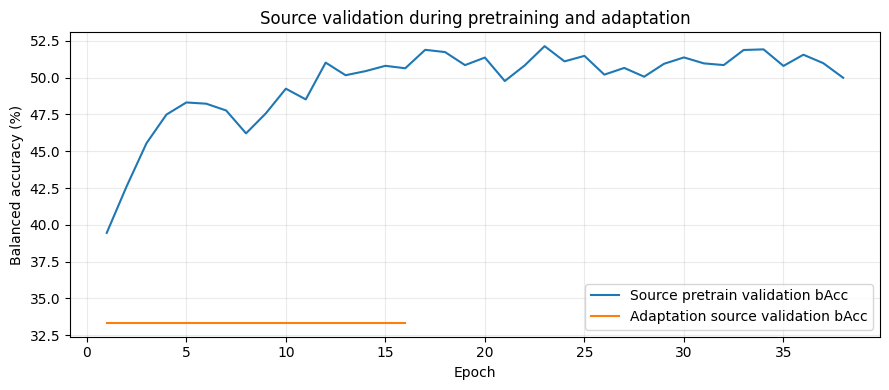

In [21]:

# ============================================================
# CELL 19 — TRAINING / ADAPTATION CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))
if len(pre_history):
    ax.plot(
        pre_history["epoch"],
        pre_history["val_bacc"],
        label="Source pretrain validation bAcc",
    )
if len(adapt_history):
    ax.plot(
        adapt_history["epoch"],
        adapt_history["val_bacc"],
        label="Adaptation source validation bAcc",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced accuracy (%)")
ax.set_title("Source validation during pretraining and adaptation")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [22]:

# ============================================================
# CELL 20 — FINAL TARGET DECISION
# ============================================================

print("=" * 78)
print("EEGMMIDB (109) → BCI-IV-2a (9) — FINAL DECISION")
print("=" * 78)

print(f"Overall BCI accuracy : {bci_overall_acc:.2f}%")
print(f"Overall BCI bAcc     : {bci_overall_bacc:.2f}%")
print(f"Mean subject acc     : {bci_subject_results['accuracy'].mean():.2f}%")
print(f"Median subject acc   : {bci_subject_results['accuracy'].median():.2f}%")
print(f"Subjects >=70%       : {(bci_subject_results['accuracy'] >= 70).sum()}/9")

if bci_overall_acc >= 70.0:
    print("\n✅ TARGET ACHIEVED: external BCI accuracy >= 70%")
else:
    print("\n❌ TARGET NOT YET ACHIEVED")
    print("Next escalation: target-aware unsupervised alignment with stronger temporal-band decomposition and/or a separate BCI calibration protocol if permitted.")


EEGMMIDB (109) → BCI-IV-2a (9) — FINAL DECISION
Overall BCI accuracy : 33.33%
Overall BCI bAcc     : 33.33%
Mean subject acc     : 33.33%
Median subject acc   : 33.33%
Subjects >=70%       : 0/9

❌ TARGET NOT YET ACHIEVED
Next escalation: target-aware unsupervised alignment with stronger temporal-band decomposition and/or a separate BCI calibration protocol if permitted.


In [23]:

# ============================================================
# CELL 21 — SAVE MODEL + RESULTS
# ============================================================

TRANSFER_OUTPUT_DIR = (
    OUTPUT_ROOT
    / "results"
    / "module_7_eegmmidb_to_bci_dann_coral_mmd"
)
TRANSFER_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

bci_subject_results.to_csv(
    TRANSFER_OUTPUT_DIR / "bci_subject_results.csv",
    index=False,
)

bci_eval_df.to_csv(
    TRANSFER_OUTPUT_DIR / "bci_predictions.csv",
    index=False,
)

adapt_history.to_csv(
    TRANSFER_OUTPUT_DIR / "adaptation_history.csv",
    index=False,
)

pre_history.to_csv(
    TRANSFER_OUTPUT_DIR / "source_pretraining_history.csv",
    index=False,
)

torch.save(
    {
        "model_state_dict": adapt_model.state_dict(),
        "classes": CLASSES,
        "source_dataset": SOURCE_DATASET,
        "target_dataset": TARGET_DATASET,
        "source_subjects": len(source_subjects),
        "target_subjects": len(target_subjects),
        "n_channels": 22,
        "n_samples": 640,
        "sfreq": TARGET_SFREQ,
        "experiment": "EEGMMIDB_to_BCI_unsupervised_domain_adaptation",
    },
    TRANSFER_OUTPUT_DIR / "adapted_eegnet.pt",
)

summary = {
    "experiment": "EEGMMIDB_109_to_BCI_IV_2a_9_DANN_CORAL_MMD",
    "source_subjects": int(len(source_subjects)),
    "target_subjects": int(len(target_subjects)),
    "overall_accuracy": float(bci_overall_acc),
    "overall_balanced_accuracy": float(bci_overall_bacc),
    "mean_subject_accuracy": float(bci_subject_results["accuracy"].mean()),
    "median_subject_accuracy": float(bci_subject_results["accuracy"].median()),
    "subjects_above_70": int((bci_subject_results["accuracy"] >= 70).sum()),
    "classes": CLASSES,
    "protocol": "unsupervised_target_domain_adaptation; target labels withheld until final evaluation",
}

with open(
    TRANSFER_OUTPUT_DIR / "summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(summary, f, indent=2)

print("Saved transfer experiment to:")
print(TRANSFER_OUTPUT_DIR)


Saved transfer experiment to:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results/module_7_eegmmidb_to_bci_dann_coral_mmd


In [24]:

# ============================================================
# CELL 22 — SANITY CHECKS FOR TARGET-LABEL ISOLATION
# ============================================================

print("Target-label isolation checks:")

print("  BCI labels available in evaluation:", len(y_target))
print("  BCI labels used for training: 0")
print("  BCI labels used for hyperparameter selection: 0")
print("  BCI labels used for temperature fitting: 0")
print("  BCI samples used for unsupervised feature alignment:", len(X_target_n))

assert SOURCE_DATASET == "EEGMMIDB"
assert TARGET_DATASET == "BCI-IV-2a"
assert len(source_subjects) == 109
assert len(target_subjects) == 9

print("\n✅ Protocol sanity checks passed.")


Target-label isolation checks:
  BCI labels available in evaluation: 1944
  BCI labels used for training: 0
  BCI labels used for hyperparameter selection: 0
  BCI labels used for temperature fitting: 0
  BCI samples used for unsupervised feature alignment: 1944

✅ Protocol sanity checks passed.


In [25]:

# ============================================================
# CELL 23 — COMPACT FINAL REPORT
# ============================================================

final_report = pd.DataFrame({
    "metric": [
        "Source subjects",
        "Target subjects",
        "Source validation bAcc before adaptation",
        "Source validation bAcc after adaptation",
        "External BCI accuracy",
        "External BCI balanced accuracy",
        "Mean subject accuracy",
        "Median subject accuracy",
        "Subjects >=70%",
    ],
    "value": [
        len(source_subjects),
        len(target_subjects),
        balanced_accuracy_score(
            y_source_val,
            P_source_val_before.argmax(1),
        ) * 100.0,
        balanced_accuracy_score(
            y_source_val,
            P_source_val_after.argmax(1),
        ) * 100.0,
        bci_overall_acc,
        bci_overall_bacc,
        bci_subject_results["accuracy"].mean(),
        bci_subject_results["accuracy"].median(),
        int((bci_subject_results["accuracy"] >= 70).sum()),
    ],
})

display(final_report)


,metric,value
0,Source subjects,109.000000
1,Target subjects,9.000000
2,Source validation bAcc before adaptation,52.141442
3,Source validation bAcc after adaptation,33.333333
4,External BCI accuracy,33.333333
5,External BCI balanced accuracy,33.333333
6,Mean subject accuracy,33.333333
7,Median subject accuracy,33.333333
8,Subjects >=70%,0.000000
